# 0.0 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from pmdarima.arima.utils import ndiffs, nsdiffs
from scipy.stats import shapiro
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings para melhor leitura do output

# # Configurando o tamanho padrão dos gráficos para melhor visualização
# from matplotlib.pylab import rcParams
# rcParams['figure.figsize'] = 15, 6

## 0.1 Funções de Apoio

In [2]:
def plotar (titulo, labelx, labely, x, y, dataset):
    sns.set_palette('Accent')
    sns.set_style('darkgrid')
    ax = sns.lineplot(x=x, y=y, data=dataset)
    ax.figure.set_size_inches(12,6)
    ax.set_title(titulo, loc='left', fontsize=18)
    ax.set_xlabel(labelx, fontsize=14)
    ax.set_ylabel(labely, fontsize=14)
    ax = ax
    

def plot_comparacao(x, y1, y2, y3, y4, dataset, titulo):
    plt.figure(figsize=(16, 12))
    
    # Subplot 1: Observação
    ax1 = plt.subplot(4, 1, 1)
    ax1.set_title(titulo, fontsize=18, loc='left')
    sns.lineplot(x=x, y=y1, data=dataset, ax=ax1)
    ax1.set_ylabel('Observação', fontsize=12)
    ax1.set_xlabel('')  # Remove label do x no primeiro gráfico
    
    # Subplot 2: Tendência
    ax2 = plt.subplot(4, 1, 2)
    sns.lineplot(x=x, y=y2, data=dataset, ax=ax2)
    ax2.set_ylabel('Tendência', fontsize=12)
    ax2.set_xlabel('')  # Remove label do x
    
    # Subplot 3: Sazonalidade
    ax3 = plt.subplot(4, 1, 3)
    sns.lineplot(x=x, y=y3, data=dataset, ax=ax3)
    ax3.set_ylabel('Sazonalidade', fontsize=12)
    ax3.set_xlabel('')  # Remove label do x
    
    # Subplot 4: Ruído
    ax4 = plt.subplot(4, 1, 4)
    sns.lineplot(x=x, y=y4, data=dataset, ax=ax4)
    ax4.set_ylabel('Ruído', fontsize=12)
    ax4.set_xlabel('Data', fontsize=12)  # Apenas o último gráfico mostra label do x
    
    # Ajusta layout para evitar sobreposição
    plt.tight_layout()
    return ax1, ax2, ax3, ax4



## 0.2 Carregando os dados

In [3]:
data = sm.datasets.elnino.load_pandas().data
data.shape

(61, 13)

In [4]:
data.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1950.0,23.11,24.20,25.37,23.86,23.03,21.57,20.63,20.15,19.67,20.03,20.02,21.80
1,1951.0,24.19,25.28,25.60,25.37,24.79,24.69,23.86,22.32,21.44,21.77,22.33,22.89
2,1952.0,24.52,26.21,26.37,24.73,23.71,22.34,20.89,20.02,19.63,20.40,20.77,22.39
3,1953.0,24.15,26.34,27.36,27.03,25.47,23.49,22.20,21.45,21.25,20.95,21.60,22.44
4,1954.0,23.02,25.00,25.33,22.97,21.73,20.77,19.52,19.33,18.95,19.11,20.27,21.30


## 0.3 preparação do dataframe para formato de séries temporais

In [5]:
# Converter ano para int
data['YEAR'] = data['YEAR'].astype('int64')

# colocar ano como indice
data.set_index('YEAR', inplace = True)
data.head()

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
YEAR,,,,,,,,,,,,
1950,23.11,24.20,25.37,23.86,23.03,21.57,20.63,20.15,19.67,20.03,20.02,21.80
1951,24.19,25.28,25.60,25.37,24.79,24.69,23.86,22.32,21.44,21.77,22.33,22.89
1952,24.52,26.21,26.37,24.73,23.71,22.34,20.89,20.02,19.63,20.40,20.77,22.39
1953,24.15,26.34,27.36,27.03,25.47,23.49,22.20,21.45,21.25,20.95,21.60,22.44
1954,23.02,25.00,25.33,22.97,21.73,20.77,19.52,19.33,18.95,19.11,20.27,21.30


In [6]:
# transpose dos meses
data1 = data.transpose()
data1.head()

YEAR,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
JAN,23.11,24.19,24.52,24.15,23.02,23.75,23.24,23.13,24.89,23.97,...,24.24,24.09,25.01,25.09,24.61,24.76,25.82,24.24,24.39,24.70
FEB,24.20,25.28,26.21,26.34,25.00,24.82,24.71,26.30,26.55,25.90,...,26.11,26.23,26.27,26.47,25.09,26.52,26.81,26.39,25.53,26.16
MAR,25.37,25.60,26.37,27.36,25.33,25.14,25.90,27.63,27.09,26.94,...,26.89,27.39,26.91,26.12,25.23,26.22,26.41,26.91,25.48,26.54
APR,23.86,25.37,24.73,27.03,22.97,24.22,24.66,27.15,26.37,25.84,...,25.99,26.44,25.41,25.27,25.21,24.29,24.96,25.68,25.84,26.04
MAY,23.03,24.79,23.71,25.47,21.73,22.16,23.14,26.72,24.71,24.23,...,23.98,25.29,23.24,23.44,24.31,23.84,23.05,24.43,24.95,24.75


In [7]:
# criar a lista de datas completas mensais ordenadas que será utilizada como index do dataframe preparado
dates = pd.date_range(start = '1950-01', freq = 'MS', periods = len(data1.columns)*12)
dates

DatetimeIndex(['1950-01-01', '1950-02-01', '1950-03-01', '1950-04-01',
               '1950-05-01', '1950-06-01', '1950-07-01', '1950-08-01',
               '1950-09-01', '1950-10-01',
               ...
               '2010-03-01', '2010-04-01', '2010-05-01', '2010-06-01',
               '2010-07-01', '2010-08-01', '2010-09-01', '2010-10-01',
               '2010-11-01', '2010-12-01'],
              dtype='datetime64[ns]', length=732, freq='MS')

In [8]:
# converter para matriz linha cada coluna do ano 
data_np = data1.transpose().to_numpy()
shape = data_np.shape
data_np[0:10]

array([[23.11, 24.2 , 25.37, 23.86, 23.03, 21.57, 20.63, 20.15, 19.67,
        20.03, 20.02, 21.8 ],
       [24.19, 25.28, 25.6 , 25.37, 24.79, 24.69, 23.86, 22.32, 21.44,
        21.77, 22.33, 22.89],
       [24.52, 26.21, 26.37, 24.73, 23.71, 22.34, 20.89, 20.02, 19.63,
        20.4 , 20.77, 22.39],
       [24.15, 26.34, 27.36, 27.03, 25.47, 23.49, 22.2 , 21.45, 21.25,
        20.95, 21.6 , 22.44],
       [23.02, 25.  , 25.33, 22.97, 21.73, 20.77, 19.52, 19.33, 18.95,
        19.11, 20.27, 21.3 ],
       [23.75, 24.82, 25.14, 24.22, 22.16, 21.2 , 20.46, 19.63, 19.24,
        19.16, 19.84, 21.19],
       [23.24, 24.71, 25.9 , 24.66, 23.14, 22.04, 21.47, 20.55, 19.89,
        19.69, 20.57, 21.58],
       [23.13, 26.3 , 27.63, 27.15, 26.72, 25.04, 23.83, 22.34, 21.8 ,
        21.8 , 22.39, 23.69],
       [24.89, 26.55, 27.09, 26.37, 24.71, 23.23, 22.31, 20.72, 20.62,
        21.05, 21.52, 22.5 ],
       [23.97, 25.9 , 26.94, 25.84, 24.23, 22.57, 21.5 , 20.15, 20.23,
        20.86, 21.88

In [9]:
# remodelar matrizes para uma única matriz coluna ordenada por ano
data_np = data_np.reshape((shape[0] * shape[1], 1))
data_np[0:10]

array([[23.11],
       [24.2 ],
       [25.37],
       [23.86],
       [23.03],
       [21.57],
       [20.63],
       [20.15],
       [19.67],
       [20.03]])

In [10]:
# transformar em dataframe a matriz coluna ordenada
df0 = pd.DataFrame({'media_temp_ocean' : data_np[:,0]})

# transformar o index em datas a partir da lista de datas completas mensais ordenadas
df0.set_index(dates, inplace = True)
df0.head(12)

,media_temp_ocean
1950-01-01,23.11
1950-02-01,24.20
1950-03-01,25.37
1950-04-01,23.86
1950-05-01,23.03
1950-06-01,21.57
1950-07-01,20.63
1950-08-01,20.15
1950-09-01,19.67
1950-10-01,20.03


# 1.0 Gráfico da série

In [11]:
df1 = df0.copy()

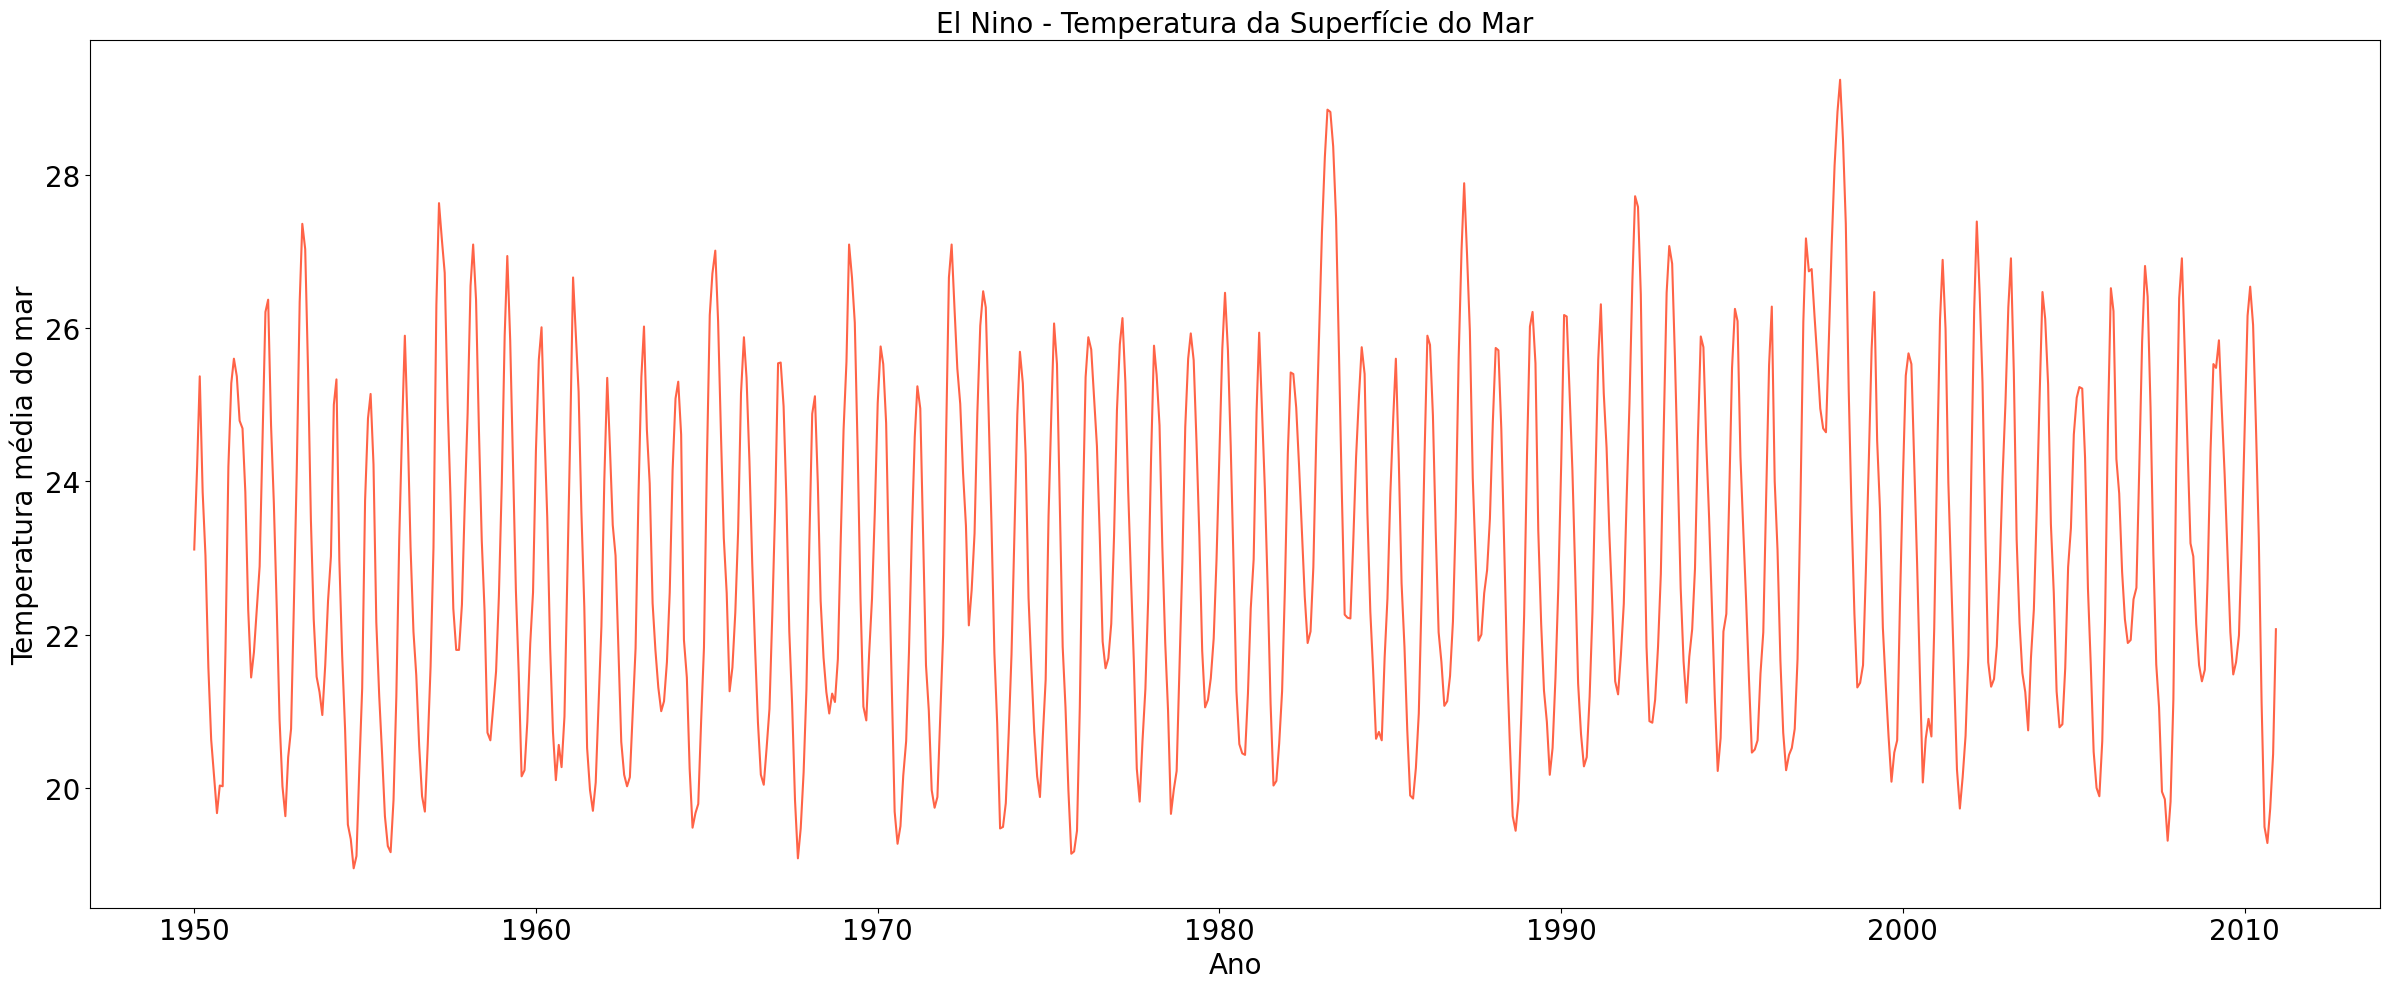

In [12]:
# PIB percapita médio x decadas
fig = plt.figure( figsize = (24,10) )
ax = sns.lineplot(data = df1, x = df1.index, y = 'media_temp_ocean', color = 'tomato');
plt.title("El Nino - Temperatura da Superfície do Mar", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Ano',fontsize=20)
plt.ylabel('Temperatura média do mar',fontsize=20)
plt.tight_layout()
plt.show();

# 2.0 Decomposição da Série Temporal

In [13]:
# definindo a séria em x
x = df1['media_temp_ocean']

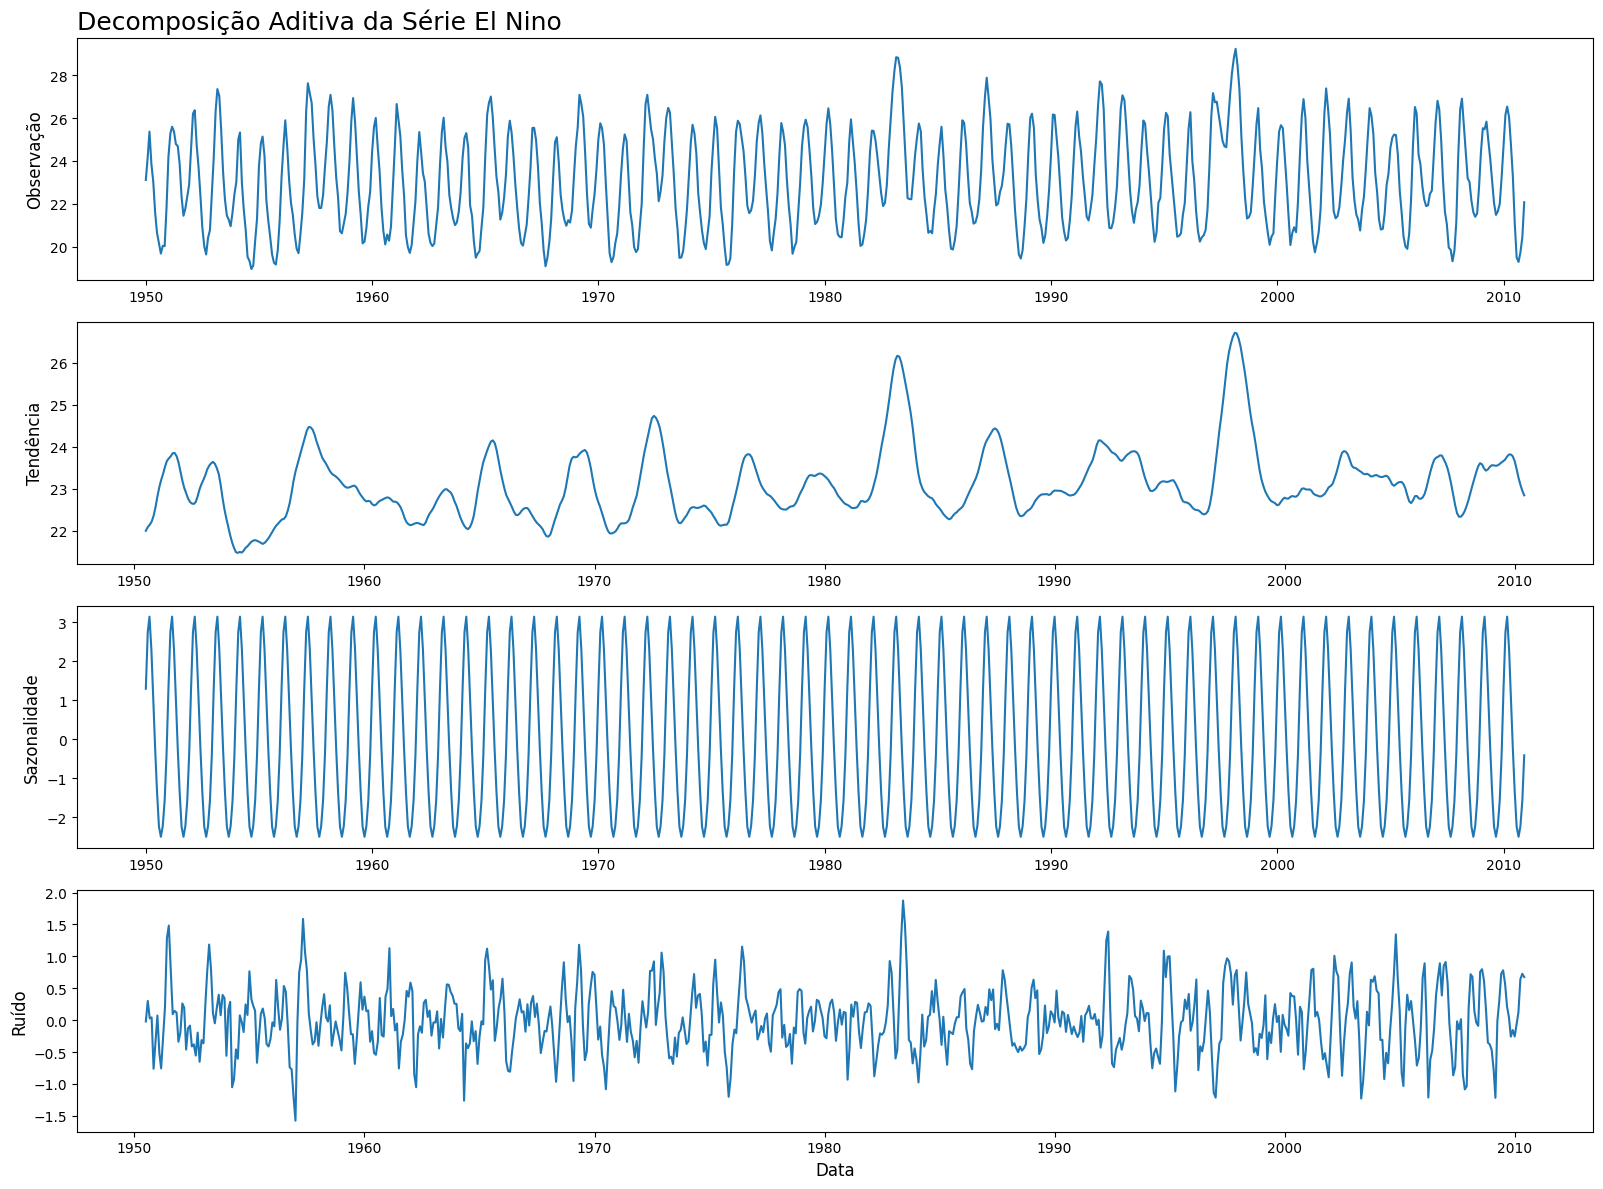

In [14]:
# Decomposição da série em tendência, sazonalidade e resíduos
resultado = seasonal_decompose(x, model='additive', period=12) # Periodo de 12 para dados mensais

observacao = resultado.observed
tendencia = resultado.trend
sazonalidade = resultado.seasonal
ruido = resultado.resid

data = ({
       'observacao':observacao,
       'tendencia':tendencia, 
       'sazonalidade':sazonalidade,
       'ruido':ruido
})
resultado = pd.DataFrame(data)
resultado.head()

plot_comparacao(resultado.index, 'observacao', 'tendencia', 'sazonalidade', 'ruido', resultado, 'Decomposição Aditiva da Série El Nino');

# 3.0 Testes de Estacionaridade e Determinação de Ordens de Diferenciação

## 3.1. Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) na Série Original

In [15]:
print('Teste KPSS na Série Original:')
kpss_stat, p_value, lags, critical_values = kpss(x, regression='c') # 'c' para estacionaridade de nível
print(f'Estatística do teste: {kpss_stat:.4f}')
print(f'p-valor: {p_value:.4f}')
print('Valores Críticos:')
for key, value in critical_values.items():
    print(f'{key}: {value:.4f}')

if p_value < 0.05:
    print("\nConclusão: Rejeitamos a hipótese nula (H0). A série NÃO É ESTACIONÁRIA (provavelmente com tendência ou raiz unitária).")
else:
    print("\nConclusão: Falhamos em rejeitar a hipótese nula (H0). A série É ESTACIONÁRIA.")


Teste KPSS na Série Original:
Estatística do teste: 0.3939
p-valor: 0.0798
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390

Conclusão: Falhamos em rejeitar a hipótese nula (H0). A série É ESTACIONÁRIA.


## 3.2. Determinação das Ordens de Diferenciação ($d$ e $D$)

In [16]:
print('Determinando a ordem de diferenciação não sazonal (d):')
d = ndiffs(x, test='kpss', max_d=5) # Max 5 diferenciações para evitar sobre-diferenciação
print(f'Número de diferenciações não sazonais necessárias (d): {d}')

print('\nDeterminando a ordem de diferenciação sazonal (D):')
m = 12 # Período sazonal para dados mensais (12 meses)
D = nsdiffs(x, m=m, test='ocsb', max_D=3) # Max 3 diferenciações sazonais
print(f'Número de diferenciações sazonais necessárias (D): {D}')


Determinando a ordem de diferenciação não sazonal (d):
Número de diferenciações não sazonais necessárias (d): 0

Determinando a ordem de diferenciação sazonal (D):
Número de diferenciações sazonais necessárias (D): 0


## 3.3. Aplicando as Diferenciações e Análise da Série Transformada

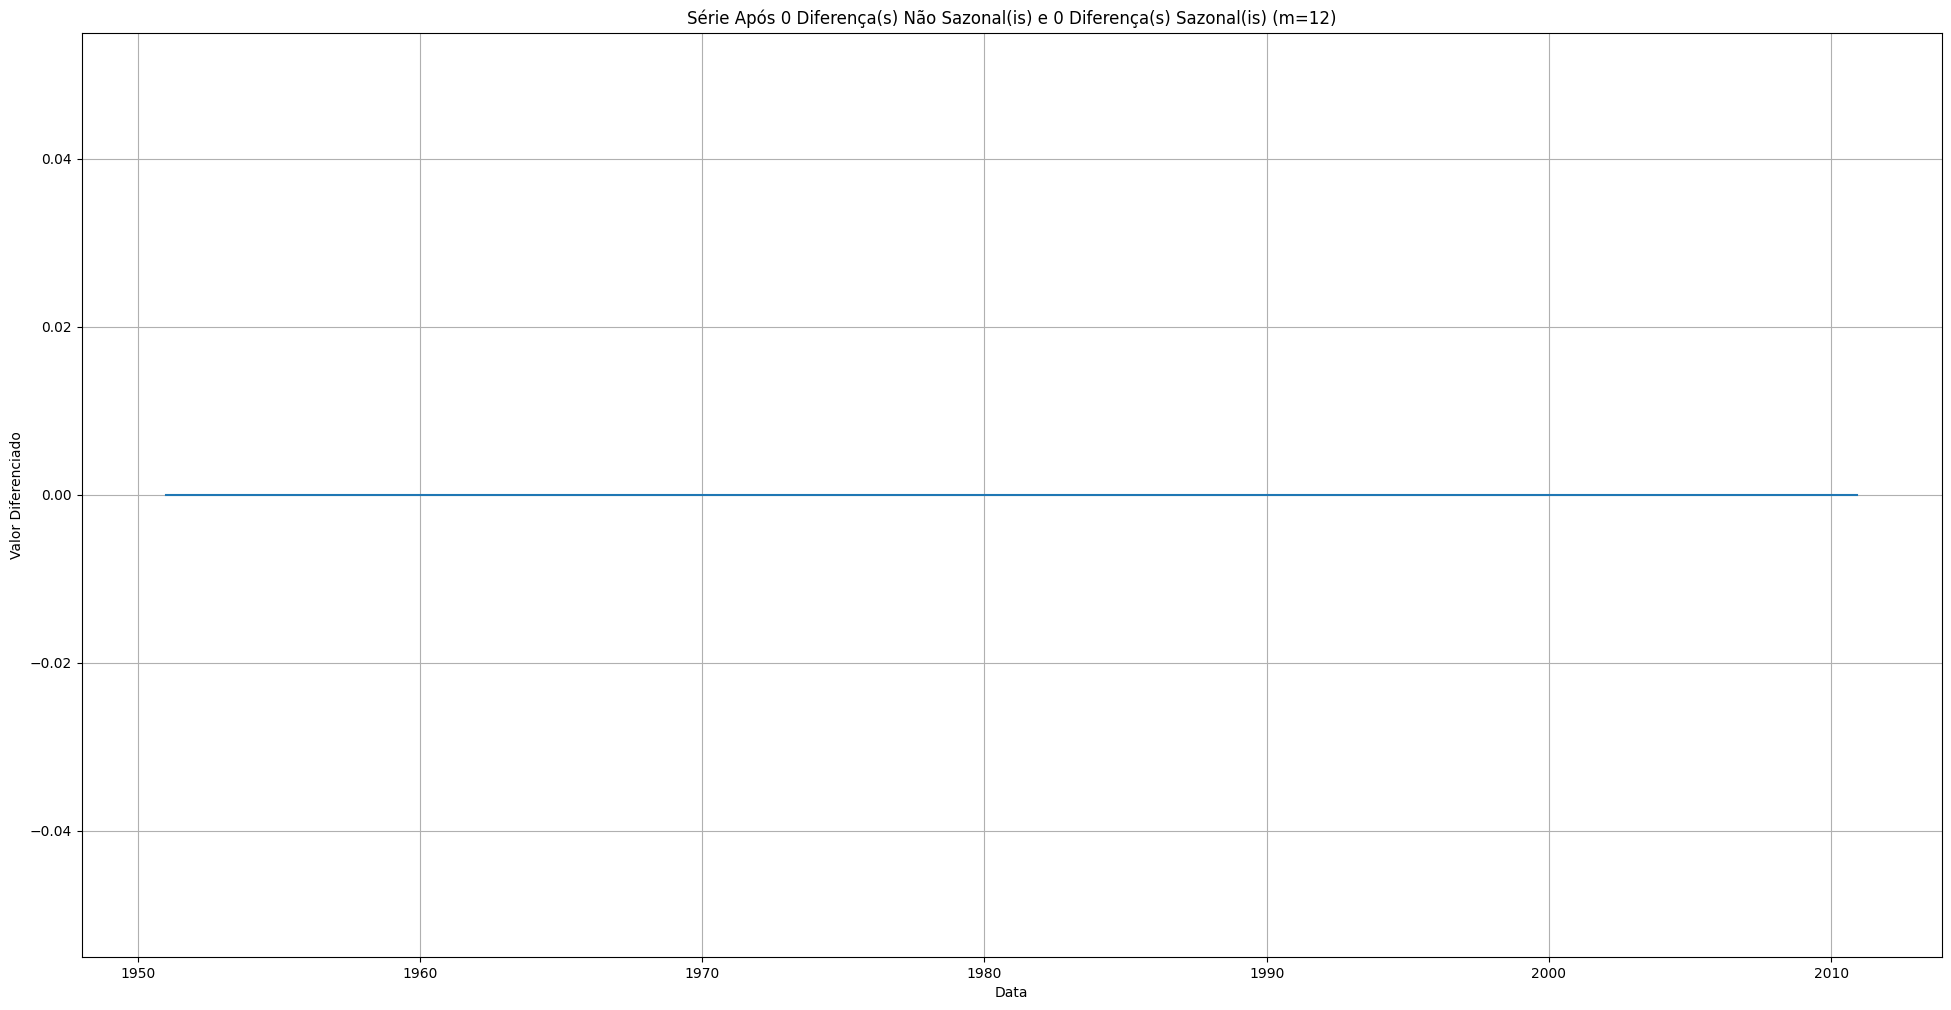

In [17]:
# Aplicando a diferenciação não sazonal e sazonal
# É importante aplicar as diferenciações na ordem correta. SARIMAX geralmente as aplica internamente.
# Para visualização, vamos aplicar as duas para ver a série transformada.

serie_dif = x.diff(d).dropna() # Aplica d diferenças não sazonais
serie_dif_sazonal = serie_dif.diff(m).dropna() # Aplica D diferenças sazonais (assumindo D=1 e m=12)

# plt.figure(figsize=(rcParams['figure.figsize']))
fig = plt.figure( figsize = (24,12) )
plt.plot(serie_dif_sazonal)

plt.title(f'Série Após {d} Diferença(s) Não Sazonal(is) e {D} Diferença(s) Sazonal(is) (m={m})')

plt.xlabel('Data')
plt.ylabel('Valor Diferenciado')
plt.grid(True)
plt.show()


ACF e PACF da Série Duplamente Diferenciada:


C:\Users\deivi\projetos\pos_ia_puc\venv_puc_disciplinas\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


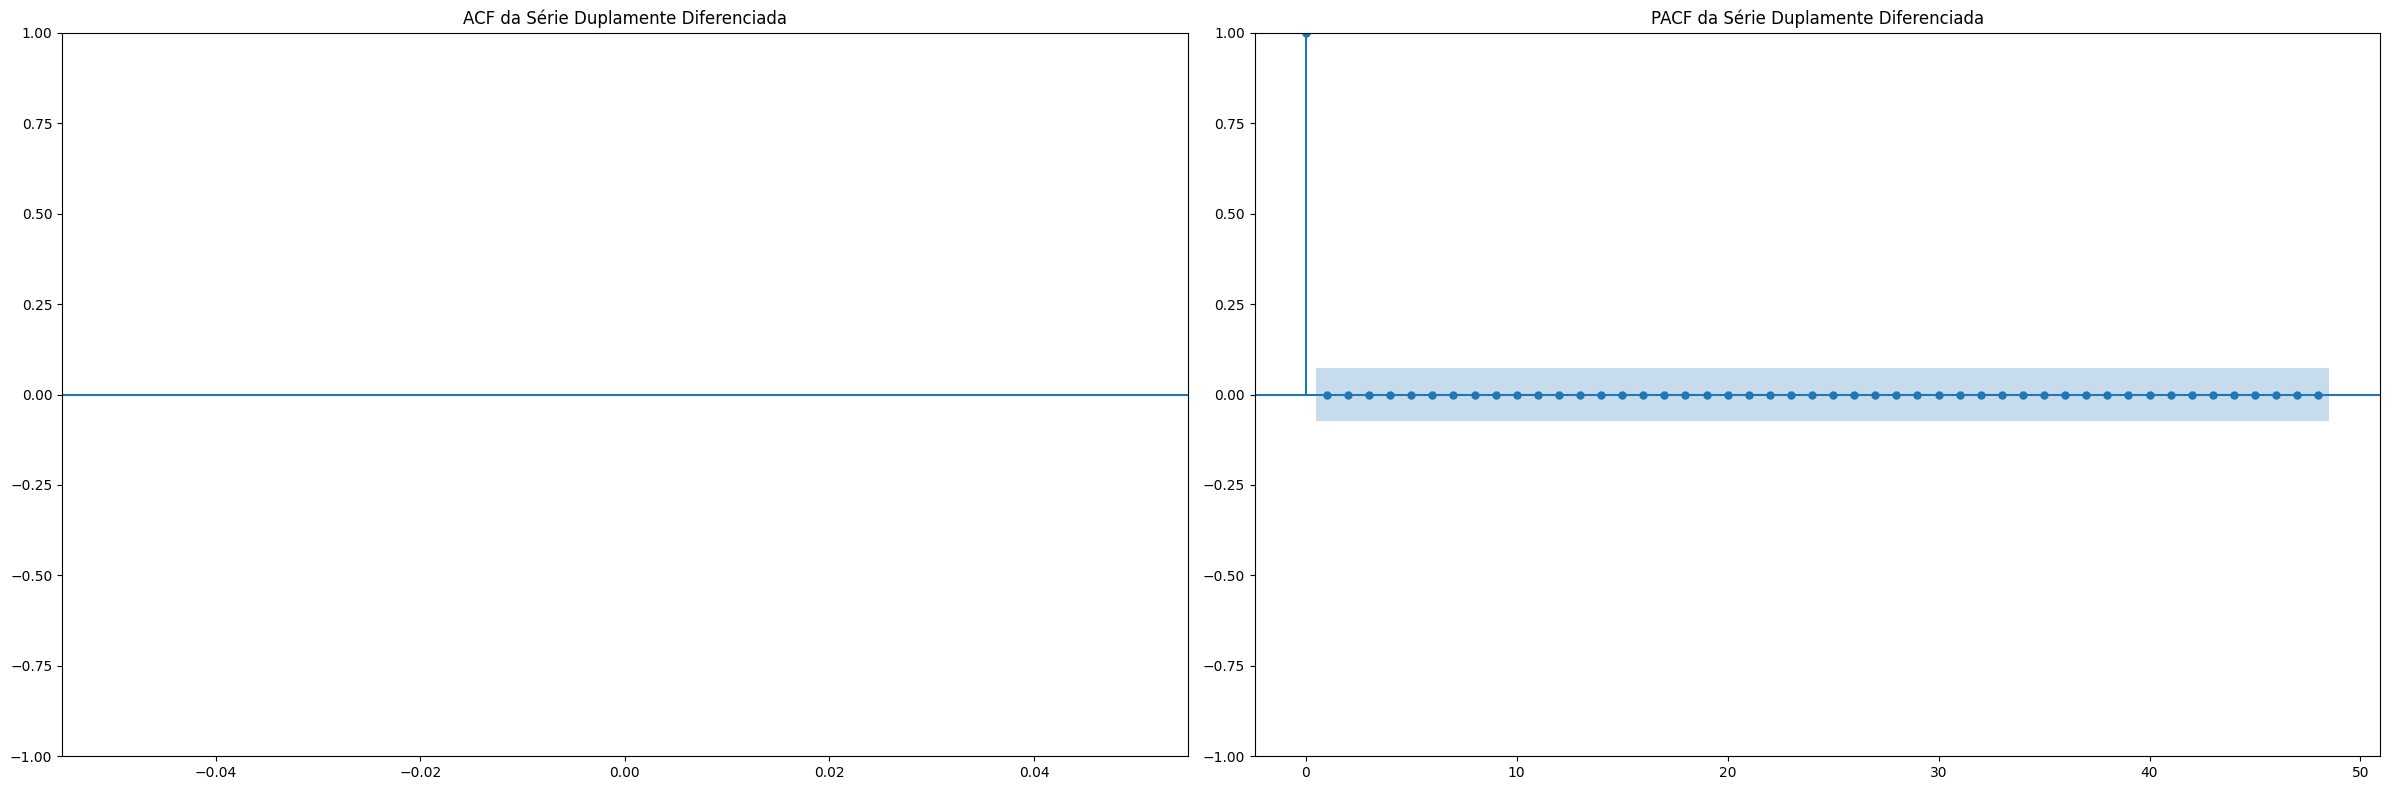

In [18]:
print('\nACF e PACF da Série Duplamente Diferenciada:')
fig = plt.figure(figsize=(24, 8))

# Criar subplots manualmente
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

plot_acf(serie_dif_sazonal, lags=4*m, ax=ax1, title='ACF da Série Duplamente Diferenciada')
plot_pacf(serie_dif_sazonal, lags=4*m, ax=ax2, title='PACF da Série Duplamente Diferenciada')

plt.tight_layout()
plt.show()

# 4.0 Ajuste dos Modelos SARIMA Candidatos

## Modelo 1

In [19]:
print('Ajustando o Modelo 1: SARIMA(1,0,0)x(0,0,0)_12')
try:
    modelo1 = SARIMAX(x, order=(1, d, 0), seasonal_order=(0, D, 0, m), 
                      enforce_stationarity=False, enforce_invertibility=False).fit()
    E_mod1 = modelo1.resid
    print("Modelo 1 ajustado com sucesso.")
except Exception as e:
    print(f"Erro ao ajustar o Modelo 1: {e}")
    E_mod1 = None

Ajustando o Modelo 1: SARIMA(1,0,0)x(0,0,0)_12
Modelo 1 ajustado com sucesso.


## 4.1. Análise Visual dos Resíduos do Modelo 1

In [20]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6


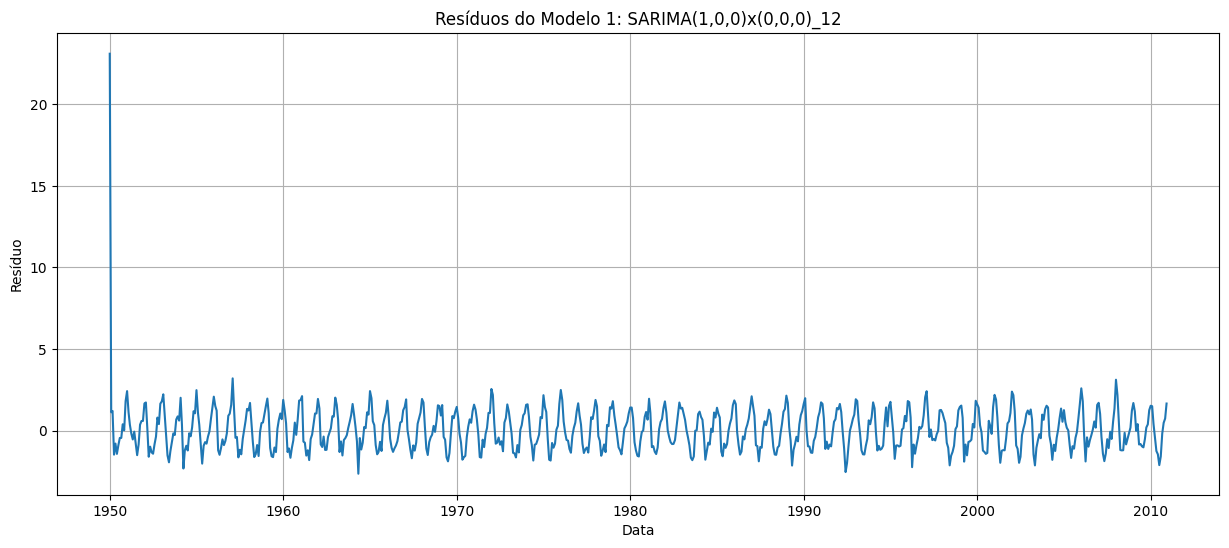

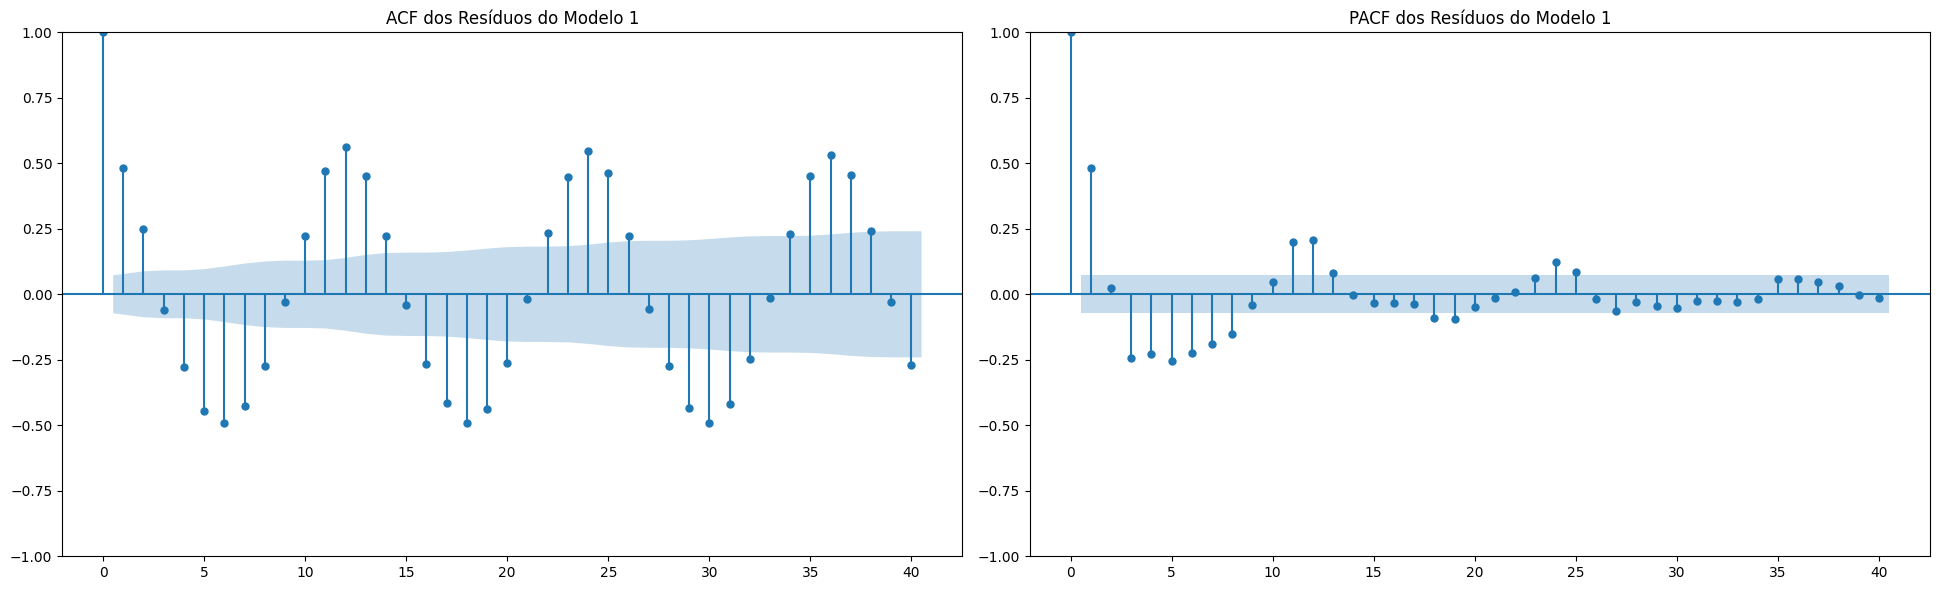

<Figure size 900x600 with 0 Axes>

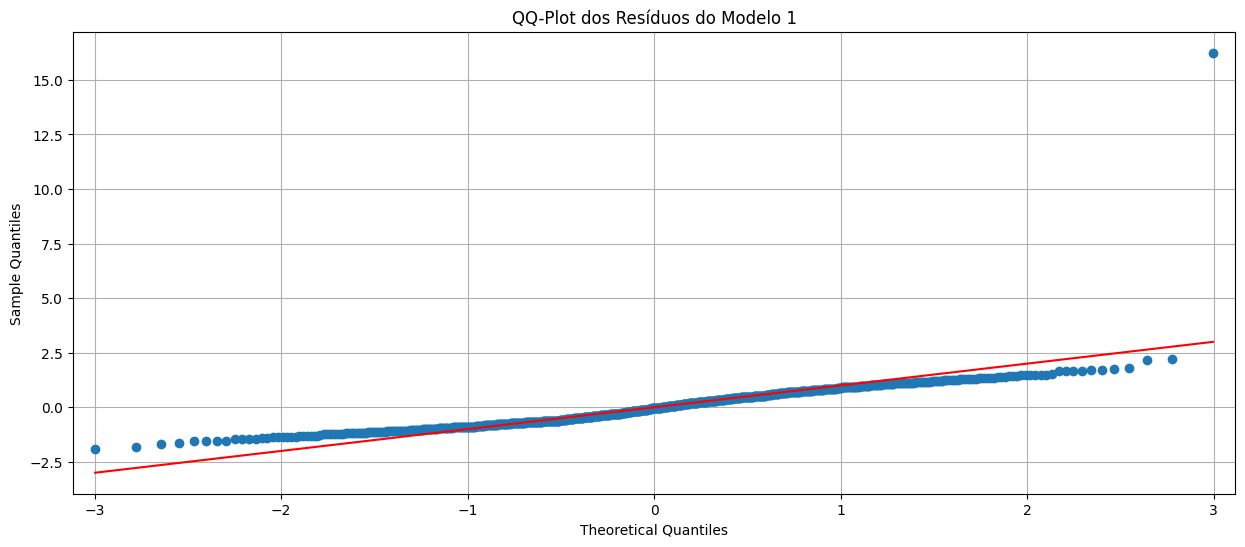

In [21]:
if E_mod1 is not None:
    # Remove os valores iniciais (d + m*D) que são 'NaN' ou resultantes da diferenciação
    E_mod1_clean = E_mod1.dropna()

    plt.figure(figsize=(rcParams['figure.figsize']))
    plt.plot(E_mod1_clean)
    plt.title('Resíduos do Modelo 1: SARIMA(1,0,0)x(0,0,0)_12')
    plt.xlabel('Data')
    plt.ylabel('Resíduo')
    plt.grid(True)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(rcParams['figure.figsize'][0]*1.3, rcParams['figure.figsize'][1]))
    plot_acf(E_mod1_clean, lags=40, ax=axes[0], title='ACF dos Resíduos do Modelo 1') # Lags suficientes
    plot_pacf(E_mod1_clean, lags=40, ax=axes[1], title='PACF dos Resíduos do Modelo 1')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(rcParams['figure.figsize'][0]*0.6, rcParams['figure.figsize'][1])) # Tamanho menor para QQ-Plot
    sm.qqplot(E_mod1_clean, line='s', fit=True)
    plt.title('QQ-Plot dos Resíduos do Modelo 1')
    plt.grid(True)
    plt.show()

## 4.2. Teste KPSS para Resíduos do Modelo 1

In [22]:
if E_mod1 is not None:
    E_mod1_clean = E_mod1.dropna()
    if len(E_mod1_clean) > 0: # Garante que há dados para testar
        print('Teste KPSS para Resíduos do Modelo 1:')
        kpss_stat, p_value, lags, critical_values = kpss(E_mod1_clean, regression='c')
        print(f'Estatística do teste: {kpss_stat:.4f}')
        print(f'p-valor: {p_value:.4f}')
        print('Valores Críticos:')
        for key, value in critical_values.items():
            print(f'{key}: {value:.4f}')
        if p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO ESTACIONÁRIOS.")
    else:
        print("Não há resíduos válidos para testar no Modelo 1.")

Teste KPSS para Resíduos do Modelo 1:
Estatística do teste: 0.0660
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.


## 4.3. Teste Ljung-Box para Resíduos do Modelo 1

In [23]:
if E_mod1 is not None:
    E_mod1_clean = E_mod1.dropna()
    if len(E_mod1_clean) > 0: # Garante que há dados para testar
        print('Teste Ljung-Box para Resíduos do Modelo 1:')
        ljung_box_result = sm.stats.acorr_ljungbox(E_mod1_clean, lags=[min(40, len(E_mod1_clean) - 1)], return_df=True) 
        print(ljung_box_result)
        if ljung_box_result['lb_pvalue'].iloc[0] > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são INDEPENDENTES (ruído branco).")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.")
    else:
        print("Não há resíduos válidos para testar no Modelo 1.")

Teste Ljung-Box para Resíduos do Modelo 1:
        lb_stat  lb_pvalue
40  3843.435108        0.0
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.


## 4.4. Teste Shapiro-Wilk para Resíduos do Modelo 1

In [24]:
if E_mod1 is not None:
    E_mod1_clean = E_mod1.dropna()
    if len(E_mod1_clean) >= 3: # Shapiro-Wilk requer pelo menos 3 pontos
        print('Teste Shapiro-Wilk para Resíduos do Modelo 1:')
        shapiro_stat, shapiro_p_value = shapiro(E_mod1_clean)
        print(f'Estatística do teste: {shapiro_stat:.4f}')
        print(f'p-valor: {shapiro_p_value:.4f}')
        if shapiro_p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são NORMALMENTE DISTRIBUÍDOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.")
    else:
        print("Não há dados suficientes nos resíduos para o teste Shapiro-Wilk no Modelo 1.")

Teste Shapiro-Wilk para Resíduos do Modelo 1:
Estatística do teste: 0.7383
p-valor: 0.0000
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.


## Modelo 2

In [25]:

print('Ajustando o Modelo 2: SARIMA(1,0,0)x(0,0,1)_12')
try:
    modelo2 = SARIMAX(x, order=(0, d, 1), seasonal_order=(0, D, 1, m), 
                      enforce_stationarity=False, enforce_invertibility=False).fit()
    E_mod2 = modelo2.resid
    print("Modelo 2 ajustado com sucesso.")
except Exception as e:
    print(f"Erro ao ajustar o Modelo 2: {e}")
    E_mod2 = None

Ajustando o Modelo 2: SARIMA(1,0,0)x(0,0,1)_12
Modelo 2 ajustado com sucesso.


## 4.5. Análise Visual dos Resíduos do Modelo 2

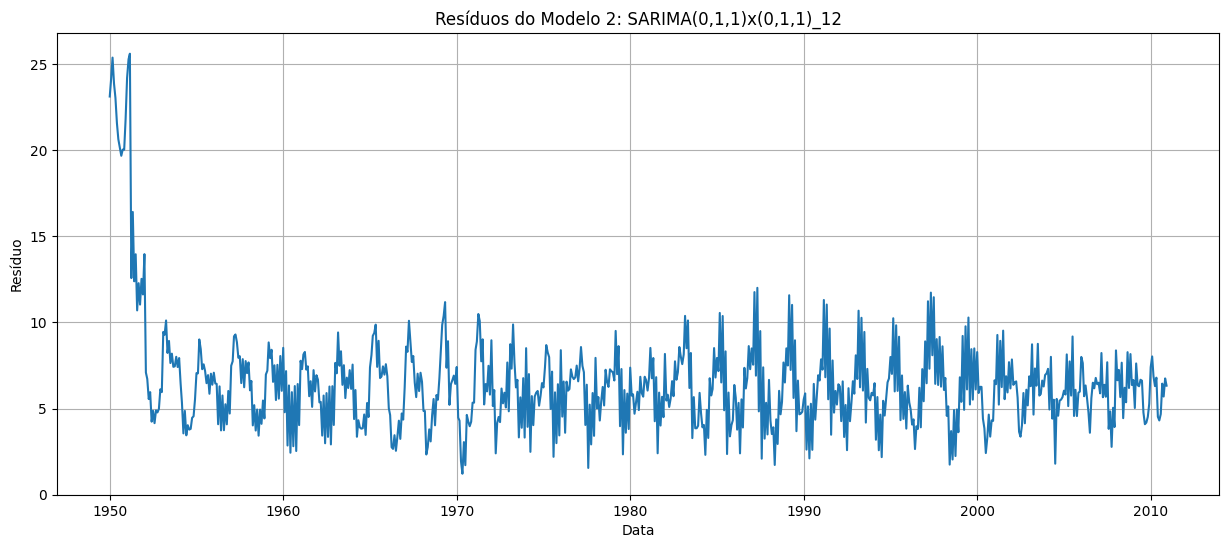

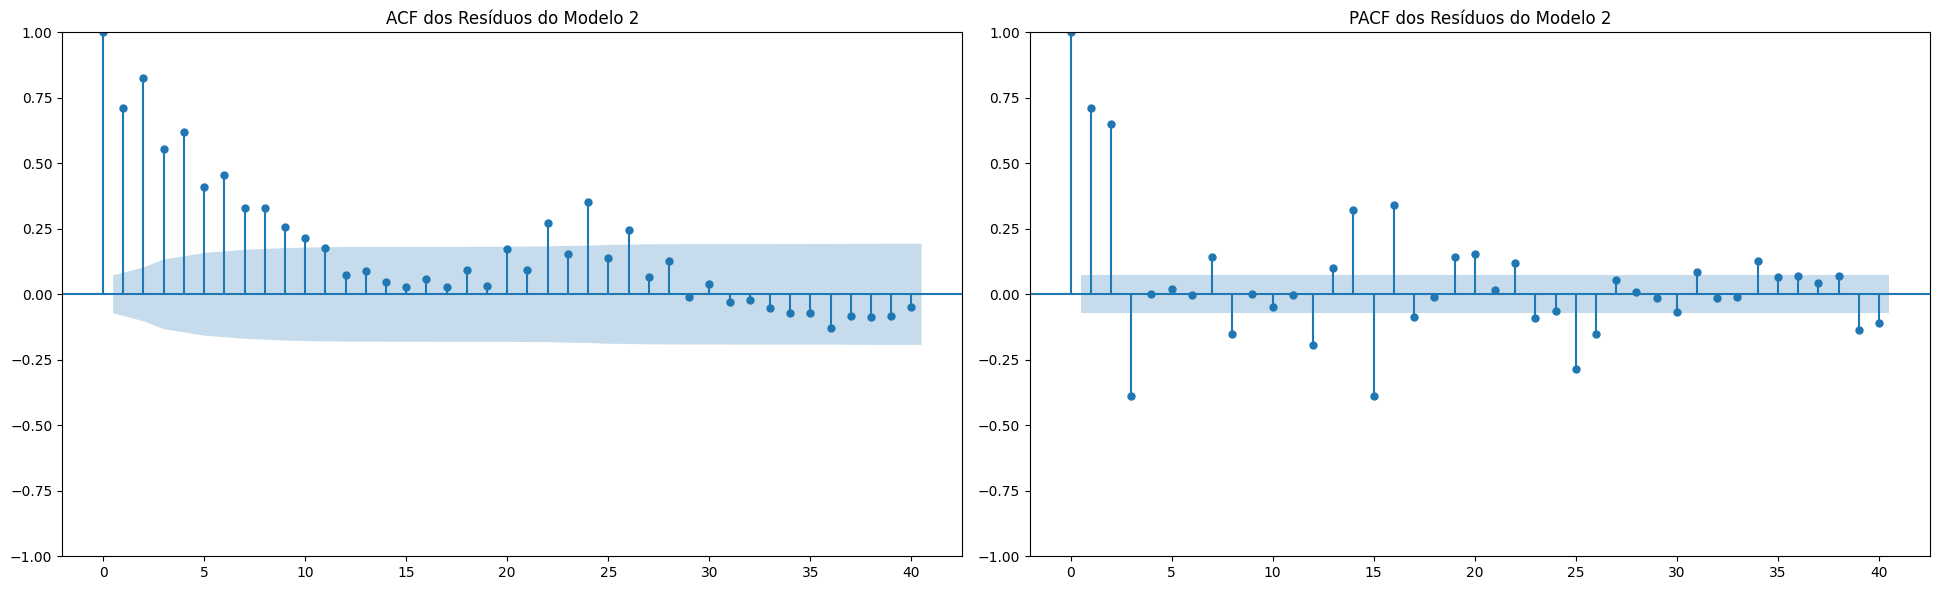

<Figure size 900x600 with 0 Axes>

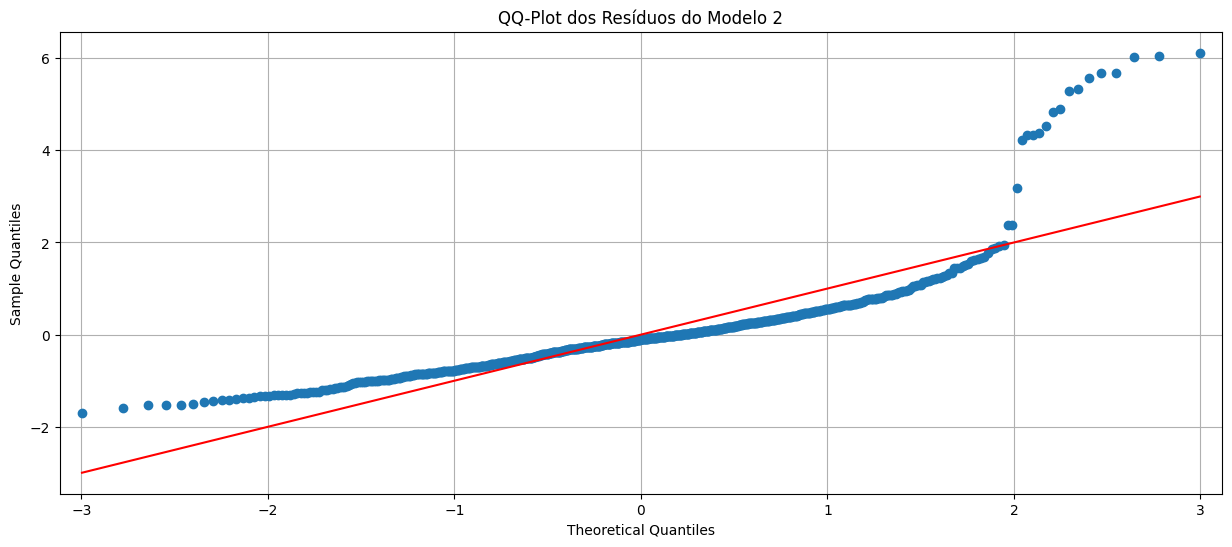

In [26]:
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()

    plt.figure(figsize=(rcParams['figure.figsize']))
    plt.plot(E_mod2_clean)
    plt.title('Resíduos do Modelo 2: SARIMA(0,1,1)x(0,1,1)_12')
    plt.xlabel('Data')
    plt.ylabel('Resíduo')
    plt.grid(True)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(rcParams['figure.figsize'][0]*1.3, rcParams['figure.figsize'][1]))
    plot_acf(E_mod2_clean, lags=40, ax=axes[0], title='ACF dos Resíduos do Modelo 2')
    plot_pacf(E_mod2_clean, lags=40, ax=axes[1], title='PACF dos Resíduos do Modelo 2')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(rcParams['figure.figsize'][0]*0.6, rcParams['figure.figsize'][1]))
    sm.qqplot(E_mod2_clean, line='s', fit=True)
    plt.title('QQ-Plot dos Resíduos do Modelo 2')
    plt.grid(True)
    plt.show()

## 4.6. Teste KPSS para Resíduos do Modelo 2

In [27]:
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()
    if len(E_mod2_clean) > 0: # Garante que há dados para testar
        print('Teste KPSS para Resíduos do Modelo 2:')
        kpss_stat, p_value, lags, critical_values = kpss(E_mod2_clean, regression='c')
        print(f'Estatística do teste: {kpss_stat:.4f}')
        print(f'p-valor: {p_value:.4f}')
        print('Valores Críticos:')
        for key, value in critical_values.items():
            print(f'{key}: {value:.4f}')
        if p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO ESTACIONÁRIOS.")
    else:
        print("Não há resíduos válidos para testar no Modelo 2.")

Teste KPSS para Resíduos do Modelo 2:
Estatística do teste: 0.5838
p-valor: 0.0241
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO ESTACIONÁRIOS.


## 4.7. Teste Ljung-Box para Resíduos do Modelo 2

In [28]:
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()
    if len(E_mod2_clean) > 0: # Garante que há dados para testar
        print('Teste Ljung-Box para Resíduos do Modelo 2:')
        ljung_box_result = sm.stats.acorr_ljungbox(E_mod2_clean, lags=[min(40, len(E_mod2_clean) - 1)], return_df=True)
        print(ljung_box_result)
        if ljung_box_result['lb_pvalue'].iloc[0] > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são INDEPENDENTES (ruído branco).")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.")
    else:
        print("Não há resíduos válidos para testar no Modelo 2.")

Teste Ljung-Box para Resíduos do Modelo 2:
        lb_stat  lb_pvalue
40  2265.539154        0.0
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.


## 4.8. Teste Shapiro-Wilk para Resíduos do Modelo 2

In [29]:
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()
    if len(E_mod2_clean) >= 3:
        print('Teste Shapiro-Wilk para Resíduos do Modelo 2:')
        shapiro_stat, shapiro_p_value = shapiro(E_mod2_clean)
        print(f'Estatística do teste: {shapiro_stat:.4f}')
        print(f'p-valor: {shapiro_p_value:.4f}')
        if shapiro_p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são NORMALMENTE DISTRIBUÍDOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.")
    else:
        print("Não há dados suficientes nos resíduos para o teste Shapiro-Wilk no Modelo 2.")

Teste Shapiro-Wilk para Resíduos do Modelo 2:
Estatística do teste: 0.7547
p-valor: 0.0000
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.


# 5.0 Resumos dos Modelos Ajustados

## Modelo 1

In [30]:
print("\nSumário do Modelo 1: SARIMA(1,1,0)x(0,1,0)_12")
print(modelo1.summary())


Sumário do Modelo 1: SARIMA(1,1,0)x(0,1,0)_12
                               SARIMAX Results                                
Dep. Variable:       media_temp_ocean   No. Observations:                  732
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1130.308
Date:                Tue, 23 Dec 2025   AIC                           2264.616
Time:                        13:16:10   BIC                           2273.805
Sample:                    01-01-1950   HQIC                          2268.161
                         - 12-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9987      0.002    551.399      0.000       0.995       1.002
sigma2         1.2900      0.092     14.087      0.000       1.110       1.469
Ljung

## Modelo 2

In [31]:
print("\nSumário do Modelo 2: SARIMA(1,1,1)x(0,1,0)_12")
print(modelo2.summary())


Sumário do Modelo 2: SARIMA(1,1,1)x(0,1,0)_12
                                     SARIMAX Results                                      
Dep. Variable:                   media_temp_ocean   No. Observations:                  732
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 12)   Log Likelihood               -2360.098
Date:                            Tue, 23 Dec 2025   AIC                           4726.196
Time:                                    13:16:10   BIC                           4739.926
Sample:                                01-01-1950   HQIC                          4731.497
                                     - 12-01-2010                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          1.0156      0.008    130.076      0.000       1.000 

# 6.0 Busca Automática de Ordem SARIMA (auto_arima)

In [32]:
print("\nIniciando busca automática de ordem para SARIMA (auto_arima)...")
# `d` e `D` são fixados pelos valores encontrados
# `start_p`, `start_q`, `start_P`, `start_Q` definem o início da busca
# `max_p`, `max_q`, `max_P`, `max_Q` definem os limites superiores
# `m` é o período sazonal
# `trace=True` exibe o progresso
# `stepwise=True` usa um algoritmo mais eficiente de busca
auto_model = auto_arima(x, 
                        d=d, D=D, 
                        start_p=0, start_q=0, 
                        max_p=3, max_q=3, 
                        start_P=0, start_Q=0, 
                        max_P=2, max_Q=2, 
                        m=m, 
                        seasonal=True, # Define que é um modelo sazonal
                        trace=True, 
                        error_action='ignore',  
                        suppress_warnings=True, 
                        stepwise=True)

print("\nSumário do Modelo SARIMA Sugerido por auto_arima:")
print(auto_model.summary())
print(f"Ordem (p,d,q) sugerida por auto_arima: {auto_model.order}")
print(f"Ordem sazonal (P,D,Q) sugerida por auto_arima: {auto_model.seasonal_order}")


Iniciando busca automática de ordem para SARIMA (auto_arima)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3264.859, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1369.431, Time=3.14 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2199.092, Time=0.57 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=6682.455, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2222.316, Time=0.39 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=3.00 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1853.767, Time=0.86 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=1022.151, Time=9.37 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=8.74 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=9.12 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=7.06 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=9.73 sec
 ARIMA(1,0,1)(2,0,1)[12] intercept   : AIC=inf, Time

## 6.1 Modelo ajustado Auto_arima

In [33]:
print('Ajustando o Modelo 3: SARIMA(1,0,0)x(2,0,1)_12')
try:
    modelo3 = SARIMAX(x, order=(1, d, 0), seasonal_order=(2, D, 1, m), 
                      enforce_stationarity=False, enforce_invertibility=False).fit()
    E_mod3 = modelo3.resid
    print("Modelo 3 ajustado com sucesso.")
except Exception as e:
    print(f"Erro ao ajustar o Modelo 2: {e}")
    E_mod3 = None

Ajustando o Modelo 3: SARIMA(1,0,0)x(2,0,1)_12
Modelo 3 ajustado com sucesso.


## 6.2. Análise Visual dos Resíduos do Modelo 2

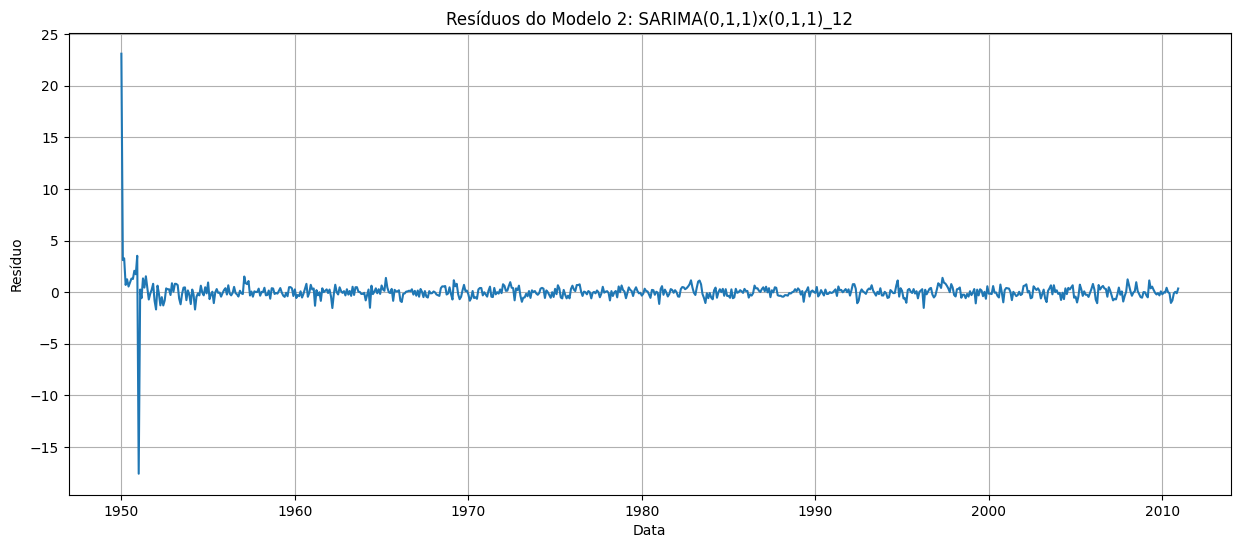

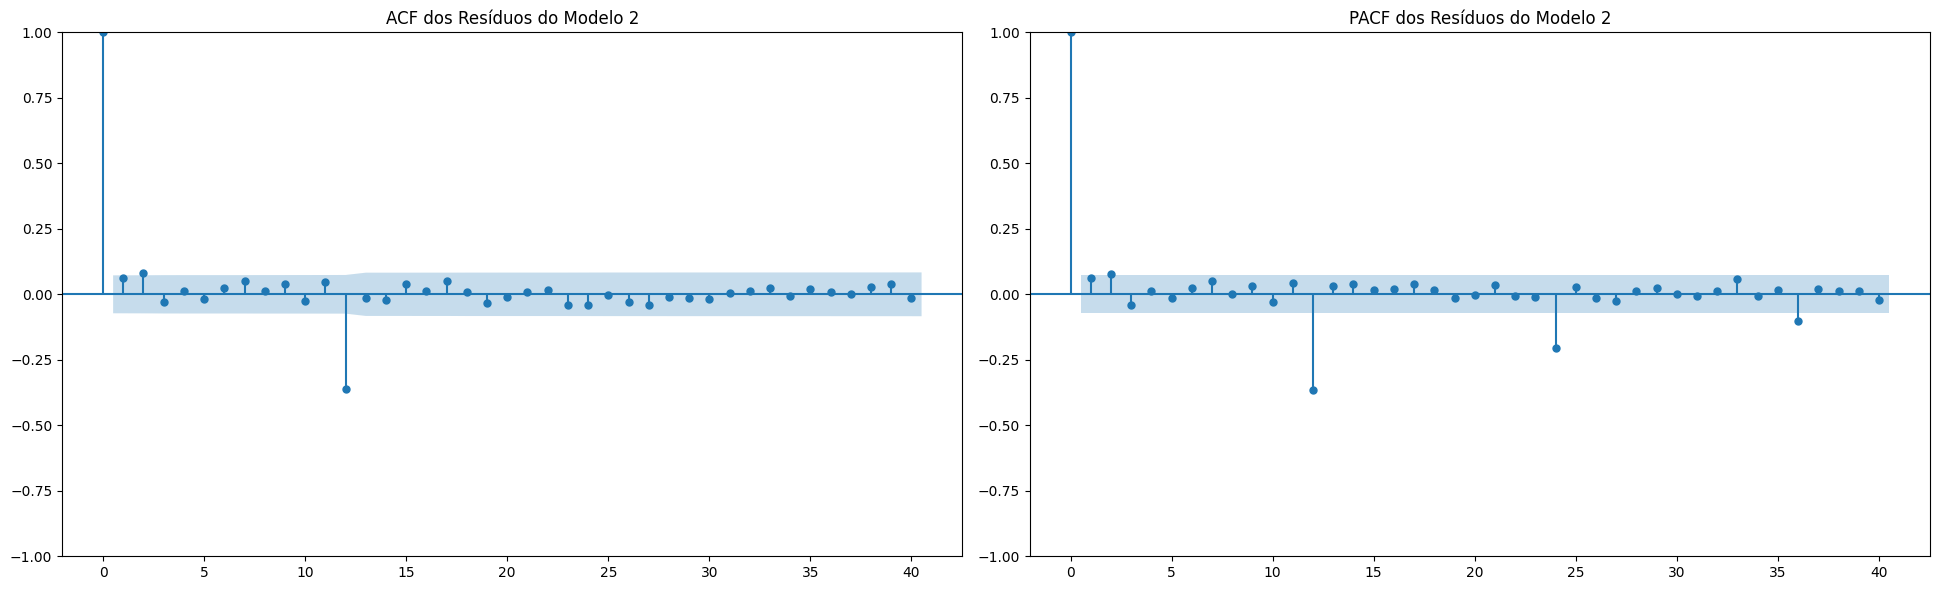

<Figure size 900x600 with 0 Axes>

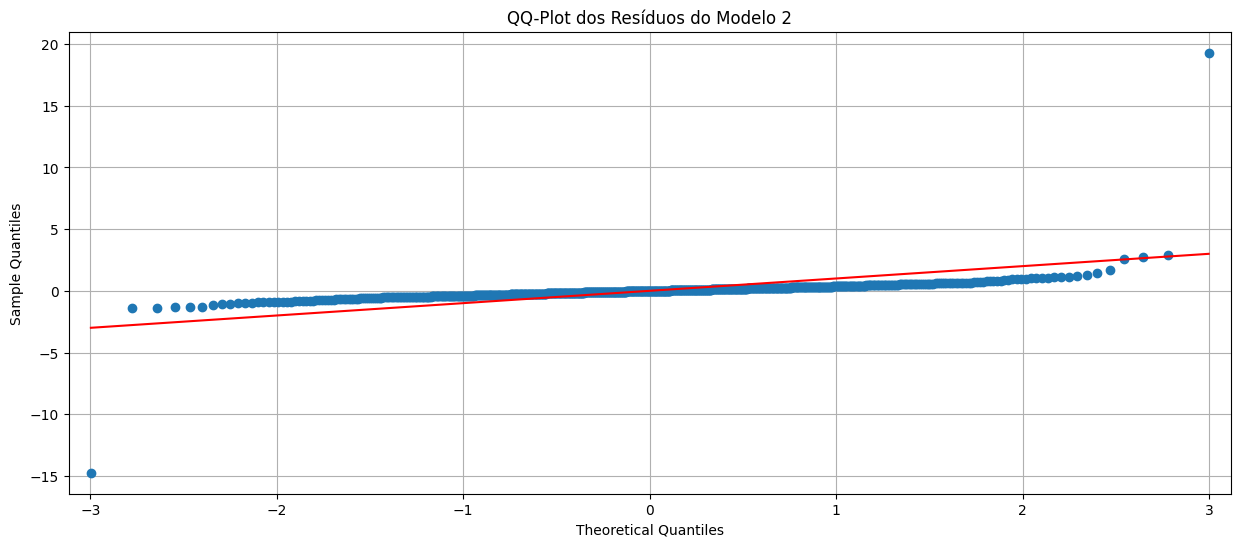

In [34]:
if E_mod3 is not None:
    E_mod3_clean = E_mod3.dropna()

    plt.figure(figsize=(rcParams['figure.figsize']))
    plt.plot(E_mod3_clean)
    plt.title('Resíduos do Modelo 2: SARIMA(0,1,1)x(0,1,1)_12')
    plt.xlabel('Data')
    plt.ylabel('Resíduo')
    plt.grid(True)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(rcParams['figure.figsize'][0]*1.3, rcParams['figure.figsize'][1]))
    plot_acf(E_mod3_clean, lags=40, ax=axes[0], title='ACF dos Resíduos do Modelo 2')
    plot_pacf(E_mod3_clean, lags=40, ax=axes[1], title='PACF dos Resíduos do Modelo 2')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(rcParams['figure.figsize'][0]*0.6, rcParams['figure.figsize'][1]))
    sm.qqplot(E_mod3_clean, line='s', fit=True)
    plt.title('QQ-Plot dos Resíduos do Modelo 2')
    plt.grid(True)
    plt.show()

## 6.3 Teste KPSS para Resíduos do Modelo 2

In [35]:
if E_mod3 is not None:
    E_mod3_clean = E_mod3.dropna()
    if len(E_mod3_clean) > 0: # Garante que há dados para testar
        print('Teste KPSS para Resíduos do Modelo 2:')
        kpss_stat, p_value, lags, critical_values = kpss(E_mod3_clean, regression='c')
        print(f'Estatística do teste: {kpss_stat:.4f}')
        print(f'p-valor: {p_value:.4f}')
        print('Valores Críticos:')
        for key, value in critical_values.items():
            print(f'{key}: {value:.4f}')
        if p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO ESTACIONÁRIOS.")
    else:
        print("Não há resíduos válidos para testar no Modelo 2.")

Teste KPSS para Resíduos do Modelo 2:
Estatística do teste: 0.1428
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.


## 6.4 Teste Ljung-Box para Resíduos do Modelo 2

In [36]:
if E_mod3 is not None:
    E_mod3_clean = E_mod3.dropna()
    if len(E_mod3_clean) > 0: # Garante que há dados para testar
        print('Teste Ljung-Box para Resíduos do Modelo 2:')
        ljung_box_result = sm.stats.acorr_ljungbox(E_mod3_clean, lags=[min(40, len(E_mod3_clean) - 1)], return_df=True)
        print(ljung_box_result)
        if ljung_box_result['lb_pvalue'].iloc[0] > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são INDEPENDENTES (ruído branco).")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.")
    else:
        print("Não há resíduos válidos para testar no Modelo 2.")

Teste Ljung-Box para Resíduos do Modelo 2:
       lb_stat     lb_pvalue
40  124.497227  1.327911e-10
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.


## 6.5 Teste Shapiro-Wilk para Resíduos do Modelo 2

In [37]:
if E_mod3 is not None:
    E_mod3_clean = E_mod3.dropna()
    if len(E_mod3_clean) >= 3:
        print('Teste Shapiro-Wilk para Resíduos do Modelo 2:')
        shapiro_stat, shapiro_p_value = shapiro(E_mod3_clean)
        print(f'Estatística do teste: {shapiro_stat:.4f}')
        print(f'p-valor: {shapiro_p_value:.4f}')
        if shapiro_p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são NORMALMENTE DISTRIBUÍDOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.")
    else:
        print("Não há dados suficientes nos resíduos para o teste Shapiro-Wilk no Modelo 2.")

Teste Shapiro-Wilk para Resíduos do Modelo 2:
Estatística do teste: 0.3307
p-valor: 0.0000
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.


In [38]:
## 6.6 Previsão modelo

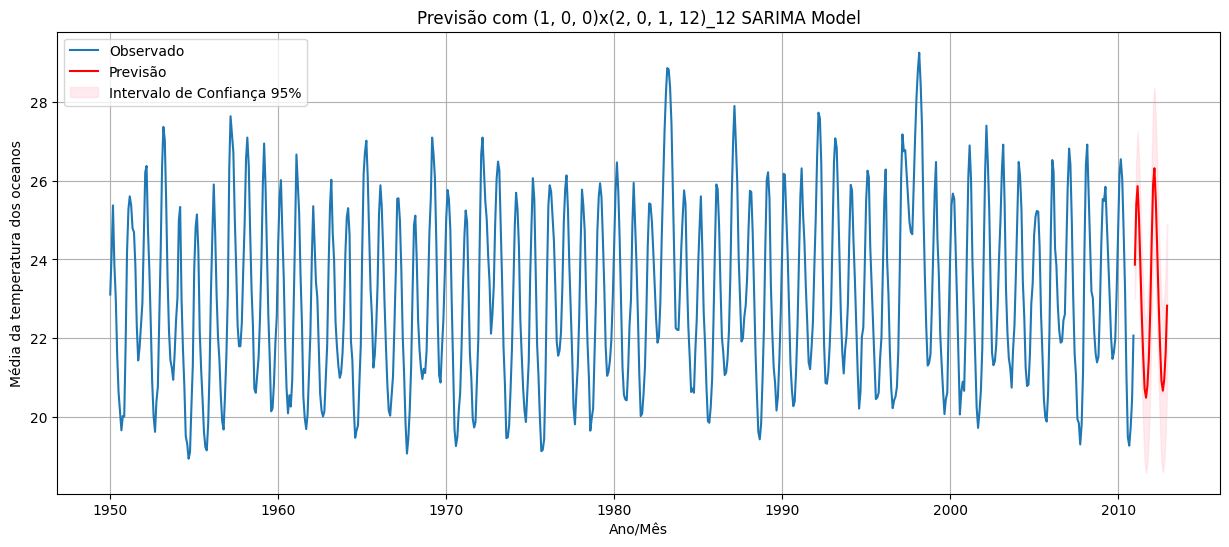

In [39]:
best_model = modelo3

forecast_steps = 24 # Prever os próximos 24 meses (2 anos)

# Gerar o índice para as previsões
last_date = x.index[-1]
# O '+ 1' em periods inclui a última data, e o '[1:]' a remove para começar após a última data observada.
forecast_index = pd.date_range(start=last_date, periods=forecast_steps + 1, freq='MS')[1:] 

# Realizar a previsão
forecast_results = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast_results.predicted_mean
forecast_conf_int = forecast_results.conf_int()

# Plotando a série observada e a previsão
plt.figure(figsize=(plt.rcParams['figure.figsize'])) # Usando plt.rcParams diretamente
plt.plot(x, label='Observado')
plt.plot(forecast_index, forecast_mean, label='Previsão', color='red')
plt.fill_between(forecast_index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confiança 95%')

# Acessando order e seasonal_order através do atributo .model do SARIMAXResults
plt.title(f'Previsão com {best_model.model.order}x{best_model.model.seasonal_order}_{m} SARIMA Model')
plt.xlabel('Ano/Mês')
plt.ylabel('Média da temperatura dos oceanos')
plt.legend()
plt.grid(True)
plt.show()